# Case Study 2: Credit Card Fraud Detection (XGBoost + SMOTE)
Dataset: Credit Card Fraud Detection (ULB), 284,807 transactions, 492 frauds.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Loaded directly from a public raw URL so the notebook runs with no manual download
df = pd.read_csv("https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()


Dataset loaded successfully!
Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nInformation:")
df.info()


Shape: (284807, 31)

Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Information:
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  flo

In [3]:
print("Missing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:", df.duplicated().sum())


Missing values:
0



Duplicate rows: 1081


Target distribution:
Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


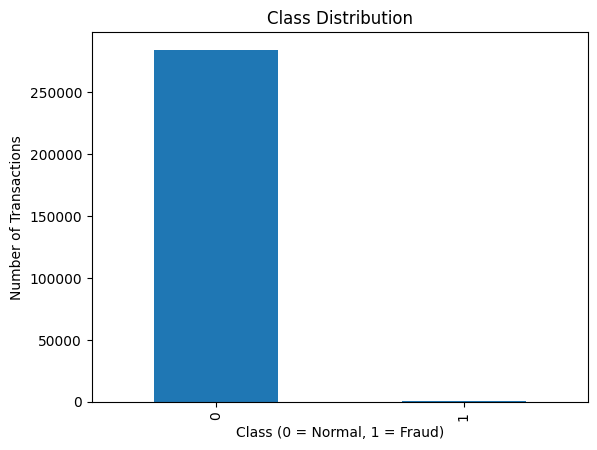

In [4]:
TARGET = "Class"

print("Target distribution:")
print(df[TARGET].value_counts())
print(df[TARGET].value_counts(normalize=True) * 100)

df[TARGET].value_counts().plot(kind="bar")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.title("Class Distribution")
plt.show()


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=[TARGET])
y = df[TARGET]

# split before any resampling, so the test set stays real and untouched
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape, " fraud cases:", y_train.sum())
print("Testing :", X_test.shape, " fraud cases:", y_test.sum())


Training: (227845, 30)  fraud cases: 394
Testing : (56962, 30)  fraud cases: 98


In [6]:
# V1-V28 are already PCA-transformed; only Time and Amount need scaling
scaler = StandardScaler()

X_train = X_train.copy()
X_test = X_test.copy()

X_train[["Time", "Amount"]] = scaler.fit_transform(X_train[["Time", "Amount"]])
X_test[["Time", "Amount"]] = scaler.transform(X_test[["Time", "Amount"]])

X_train[["Time", "Amount"]].describe()


,Time,Amount
count,2.278450e+05,2.278450e+05
mean,-1.409578e-16,3.742243e-17
std,1.000002e+00,1.000002e+00
min,-1.998073e+00,-3.516894e-01
25%,-8.561495e-01,-3.291944e-01
50%,-2.122647e-01,-2.639429e-01
75%,9.366285e-01,-4.262209e-02
max,1.640549e+00,1.021170e+02


In [7]:
from imblearn.over_sampling import SMOTE

# SMOTE applied to training data only, so the test set is never touched
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE :", y_train_res.value_counts().to_dict())


Before SMOTE: {0: 227451, 1: 394}
After SMOTE : {0: 227451, 1: 227451}


In [8]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_res, y_train_res)

print("Training completed")


Training completed


In [9]:
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Fraud Probability": y_prob
})

results.head(20)


,Actual,Predicted,Fraud Probability
0,0,0,9.373195e-06
1,0,0,2.972139e-07
2,0,0,3.538029e-06
3,0,0,1.369554e-07
4,0,0,1.040973e-04
5,0,0,1.773260e-05
6,0,0,9.997375e-07
7,0,0,4.625646e-06
8,0,0,3.343880e-05
9,0,0,4.535429e-05


In [10]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    classification_report, confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
print("F1-score :", f1_score(y_test, y_pred, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print("AUPRC    :", average_precision_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))


Accuracy : 0.9988939995084443
Precision: 0.6296296296296297
Recall   : 0.8673469387755102
F1-score : 0.7296137339055794
ROC-AUC  : 0.9800713194675732
AUPRC    : 0.8591723765988251

Classification Report:
              precision    recall  f1-score   support

           0     0.9998    0.9991    0.9994     56864
           1     0.6296    0.8673    0.7296        98

    accuracy                         0.9989     56962
   macro avg     0.8147    0.9332    0.8645     56962
weighted avg     0.9991    0.9989    0.9990     56962



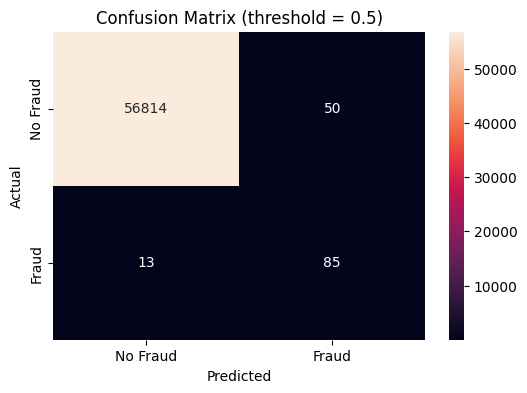

In [11]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No Fraud", "Fraud"],
    yticklabels=["No Fraud", "Fraud"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (threshold = 0.5)")
plt.show()


Best threshold by F1: 0.99309266
Precision at this threshold: 0.9506172839506173
Recall at this threshold   : 0.7857142857142857
F1 at this threshold       : 0.8603351955302306


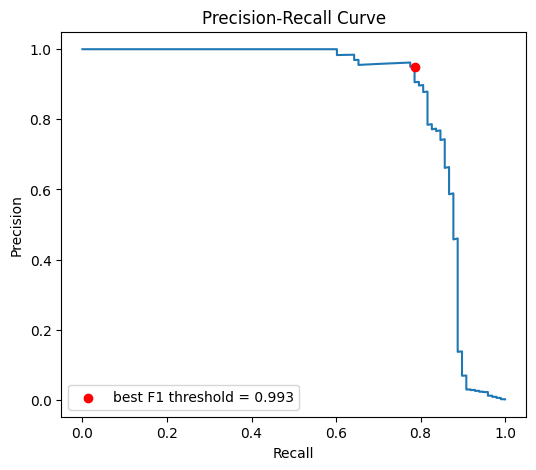

In [12]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-12)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]

print("Best threshold by F1:", best_threshold)
print("Precision at this threshold:", precisions[best_idx])
print("Recall at this threshold   :", recalls[best_idx])
print("F1 at this threshold       :", f1_scores[best_idx])

plt.figure(figsize=(6,5))
plt.plot(recalls, precisions)
plt.scatter(recalls[best_idx], precisions[best_idx], color="red", zorder=5, label=f"best F1 threshold = {best_threshold:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()


In [13]:
y_pred_tuned = (y_prob >= best_threshold).astype(int)

print("Confusion matrix at tuned threshold:")
print(confusion_matrix(y_test, y_pred_tuned))
print(classification_report(y_test, y_pred_tuned, digits=4))


Confusion matrix at tuned threshold:
[[56860     4]
 [   21    77]]


              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     56864
           1     0.9506    0.7857    0.8603        98

    accuracy                         0.9996     56962
   macro avg     0.9751    0.8928    0.9301     56962
weighted avg     0.9995    0.9996    0.9995     56962



In [14]:
# fraud teams often care more about catching fraud than avoiding false alarms,
# so here's the threshold that guarantees at least 90% recall
target_recall = 0.90
idx_candidates = np.where(recalls >= target_recall)[0]
idx = idx_candidates[np.argmax(precisions[idx_candidates])]
recall_threshold = thresholds[idx] if idx < len(thresholds) else 0.0

y_pred_recall = (y_prob >= recall_threshold).astype(int)

print("Threshold for recall >= 90%:", recall_threshold)
print(confusion_matrix(y_test, y_pred_recall))
print(classification_report(y_test, y_pred_recall, digits=4))


Threshold for recall >= 90%: 0.0128866555
[[55670  1194]
 [    9    89]]
              precision    recall  f1-score   support

           0     0.9998    0.9790    0.9893     56864
           1     0.0694    0.9082    0.1289        98

    accuracy                         0.9789     56962
   macro avg     0.5346    0.9436    0.5591     56962
weighted avg     0.9982    0.9789    0.9878     56962



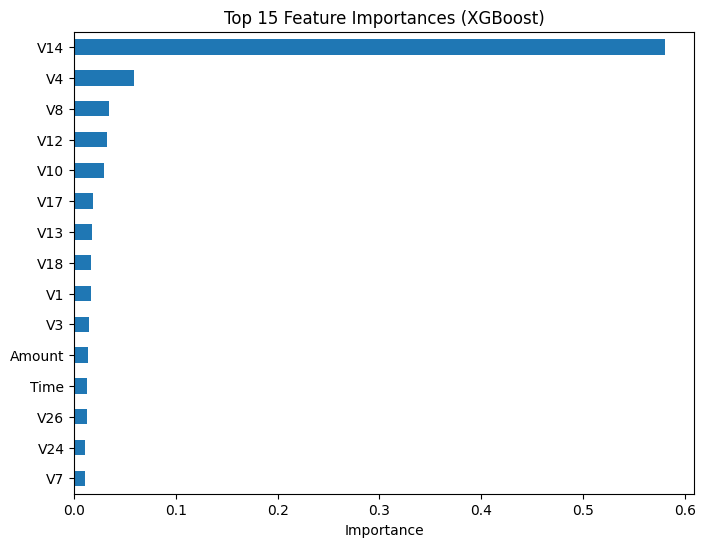

V14    0.580362
V4     0.058892
V8     0.034578
V12    0.032090
V10    0.029330
V17    0.018589
V13    0.017333
V18    0.016847
V1     0.016748
V3     0.014196
dtype: float32

In [15]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,6))
importances.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.show()

importances.head(10)
